# [실습 14-1] 데이터 편향 시각화와 공정성 지표 계산

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 14.2 편향과 공정성 |
| 선수 실습 | [실습 6-1] (혼동 행렬·평가지표 재사용) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 데이터 다운로드(수 MB) |

"공정한가?"를 느낌이 아니라 **숫자로** 따진다 —
실제 인구조사 데이터(UCI Adult)에서 집단별 격차를 시각화하고,
6장에서 배운 혼동 행렬로 공정성 지표 두 가지를 직접 계산한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch14/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from utils import plot_style, viz, fairness
from utils.data import fix_ssl, load_adult, prepare_features

plot_style.apply()              # 도해 스타일 킷 적용
fix_ssl()                       # 로컬 macOS 다운로드 대비
# 다운로드 실패 시: load_adult()가 저장소 동봉 사본
# data/adult.csv 로 자동 대체한다(대체 URL 불필요)
print("Python", platform.python_version())
print("pandas", pd.__version__,
      "/ scikit-learn", sklearn.__version__)

Python 3.12.6
pandas 3.0.3 / scikit-learn 1.9.0


### [셀 1] 데이터의 편향부터 눈으로 — 집단별 고소득 비율 📖

sex
Female    0.109
Male      0.304
Name: income, dtype: float64


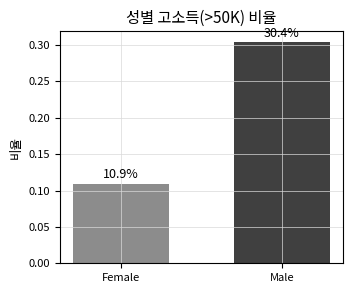

<Axes: title={'center': '성별 고소득(>50K) 비율'}, ylabel='비율'>

In [2]:
df = load_adult()      # [준비] 셀의 공용 로더(UCI Adult)
rate = (df.groupby("sex")["income"]
          .apply(lambda s: (s == ">50K").mean()))
print(rate.round(3))
viz.plot_group_rates(rate,
                     title="성별 고소득(>50K) 비율")

**핵심 포인트**
- 학습을 시작하기도 전에, 데이터 자체에 고소득 라벨의 성별 격차가 약 3배(10.9% vs 30.4%)로 담겨 있다. 1994년 미국 사회의 역사적 편향이 그대로 기록된 것이다.
- 이 데이터로 "고소득 여부"를 예측하는 모델을 학습하면 무엇을 배울지, 다음 셀 전에 예측해 보자.

### [보조 1] 데이터 분할과 평가 준비 (저장소 전용)

[셀 2]·[셀 3]이 쓰는 분할 데이터와 지면 호출명을 준비한다 — **건너뛰지 말고 실행**한다.

In [3]:
from functools import partial
from sklearn.model_selection import train_test_split

X, y, sex = prepare_features(df, drop=["sex", "race"])
(X_train, X_test, y_train, y_test,
 sex_train, sex_test) = train_test_split(
    X, y, sex, test_size=0.3, random_state=42,
    stratify=y)

# 지면 호출명 준비 — 평가 라벨(y_test)을 미리 묶는다
demographic_parity_diff = fairness.demographic_parity_diff
fairness_report = partial(fairness.fairness_report,
                          y_true=y_test)
threshold_adjust = partial(fairness.threshold_adjust,
                           y_true=y_test)
print(f"학습 {len(X_train):,}명 / 평가 {len(X_test):,}명"
      f" (분할 시드 42 고정)")

학습 34,189명 / 평가 14,653명 (분할 시드 42 고정)


### [셀 2] 민감 특징을 빼고 학습하면 공정해질까 📖

In [4]:
X, y, sex = prepare_features(df, drop=["sex", "race"])
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)          # 성별·인종 없이 학습

pred = model.predict(X_test)
dp = demographic_parity_diff(pred, sex_test)
print(f"예측 양성률 차이(남-여): {dp:.3f}")

예측 양성률 차이(남-여): 0.076


**핵심 포인트**
- 성별·인종 컬럼을 **빼고** 학습했는데도 집단 간 예측 격차 0.076이 남는다. 직업·근로시간·혼인 상태 같은 남은 특징들이 성별과 상관되어 있어 **대리 특징**(Proxy) 노릇을 하기 때문이다.
- "민감 컬럼 삭제"가 공정성 처방으로 불충분한 이유가 숫자로 확인된 것이다. 본문 〈편향의 유입 경로〉의 경고 그대로다.

### [셀 3] 두 지표는 동시에 잡히지 않는다 — 상충의 실측 📖

In [5]:
base = fairness_report(model, X_test, sex_test)
print(f"[기준] 동등성 차이 {base.dp:.3f} / "
      f"균등 기회 차이 {base.eo:.3f}")

adj = threshold_adjust(model, X_test, sex_test,
                       target="demographic_parity")
print(f"[조정] 동등성 차이 {adj.dp:.3f} / "
      f"균등 기회 차이 {adj.eo:.3f}")

[기준] 동등성 차이 0.076 / 균등 기회 차이 0.007


[조정] 동등성 차이 0.000 / 균등 기회 차이 -0.148


**핵심 포인트**
- 기준 모델은 균등 기회 차이가 0.007 ≈ 0으로 이 지표로는 거의 공정했다 — **지표마다 재는 것이 달라 결론도 다르다.**
- 집단별 판정 임계값을 조정해 동등성 차이를 0(이산 데이터의 최근접값)으로 맞추면, 균등 기회 차이가 크게 벌어진다. 하나를 잡으니 다른 하나가 달아난다 — 〈공정성의 측정〉의 불가능성 정리가 실데이터에서 재현된 것이다.
- 어느 지표를 우선할지는 코드가 정해 주지 않는다. 대출·채용·재범 예측 각각에서 어떤 선택이 정의로운지 — 연습문제와 토론의 몫이다.

### [보조 2] 인종 집단 확장과 전처리 상세

In [6]:
race_rate = (df.assign(high=(df["income"] == ">50K")
                        .astype(int))
               .groupby("race")["high"]
               .agg(["mean", "size"]).sort_values("mean"))
print(race_rate.round(3))
# 표본이 작은 집단(수백 명)은 지표의 분산이 크다 —
# 보고 시 집단 병합·신뢰구간 병기가 실무 관행이다.
print("\n결측 현황:",
      df[["workclass", "occupation"]]
      .isna().sum().to_dict())
# 본 실습은 수치형 특징만 사용해 결측 영향이 없다.
# 범주형까지 쓰려면 원-핫 인코딩 후 동일 절차를 밟는다.

                     mean   size
race                            
Amer-Indian-Eskimo  0.117    470
Black               0.121   4685
Other               0.123    406
White               0.254  41762
Asian-Pac-Islander  0.269   1519

결측 현황: {'workclass': 2799, 'occupation': 2809}


### [보조 3] 임계값 스윕 — 두 지표의 줄다리기 곡선

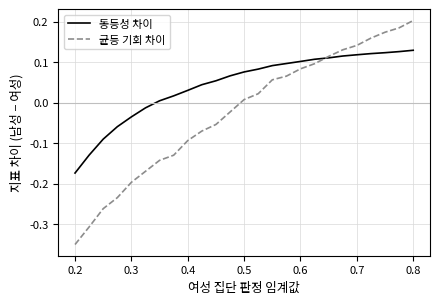

In [7]:
ts = np.linspace(0.2, 0.8, 25)
reps = [fairness_report(model, X_test, sex_test,
                        thresholds=(0.5, t)) for t in ts]
dps = [r.dp for r in reps]
eos = [r.eo for r in reps]

fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(ts, dps, "-", color="black", lw=1.2,
        label="동등성 차이")
ax.plot(ts, eos, "--", color="#8c8c8c", lw=1.2,
        label="균등 기회 차이")
ax.axhline(0, color="#bfbfbf", lw=0.8)
ax.set_xlabel("여성 집단 판정 임계값")
ax.set_ylabel("지표 차이 (남성 − 여성)")
ax.legend()
plt.show()

두 곡선이 0을 지나는 지점이 **서로 다르다** — 어떤 임계값을 골라도 두 지표를 동시에 0으로 만들 수 없다.

### [심화 1] 다른 민감 속성·균등화 오즈 (연습문제 응용 직결)

In [8]:
# TODO 1: 민감 속성을 race로 바꿔 [셀 2]~[셀 3]을
#         재수행하자([보조 1]의 표본 크기 주의 참고).
# TODO 2: 균등화 오즈(TPR과 FPR 모두 일치 요구)를
#         계산해 균등 기회보다 왜 더 엄격한지 논증하자.
from sklearn.metrics import confusion_matrix

def fpr(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

def tpr(cm):
    tn, fp, fn, tp = cm.ravel()
    return tp / (tp + fn)

for g in ("Male", "Female"):
    m = (sex_test == g).values
    cm = confusion_matrix(y_test[m], pred[m])
    print(f"{g:<8} TPR {tpr(cm):.3f} / "
          f"FPR {fpr(cm):.3f}")

Male     TPR 0.391 / FPR 0.053
Female   TPR 0.383 / FPR 0.040


---